In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns





In [3]:
flight_df = pd.read_csv(r"D:\predictionFlight\dataPriceFlight.csv")
flight_df.head(10)

,Flight Code,Airline Name,Departure Time,Arrival Time,Duration,Stops,Price,Departure City,Arrival City,Travel Class,Date of Travel
0,"VJ-519, VJ-720",VietJet Air,20:05,11:40,15h 35m,1,1634479,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
1,"VJ-521, VJ-720",VietJet Air,20:50,11:40,14h 50m,1,1857136,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
2,"VJ-501, VJ-720",VietJet Air,20:35,11:40,15h 5m,1,1857136,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
3,"VJ-519, VJ-722",VietJet Air,20:05,18:30,22h 25m,1,1885594,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
4,"VJ-519, VN-1670","VietJet Air, Vietnam Airlines",20:05,10:45,14h 40m,1,1904911,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
5,"VU-639, VJ-720","Vietravel Airlines, VietJet Air",16:50,11:40,18h 50m,1,2020108,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
6,"QH-147, VJ-720","Bamboo Airways, VietJet Air",16:15,11:40,19h 25m,1,2046252,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
7,"VU-635, VJ-720","Vietravel Airlines, VietJet Air",06:25,12:10,5h 45m,1,2131445,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
8,"VJ-503, VJ-720",VietJet Air,05:55,12:10,6h 15m,1,2313690,Hà Nội,Hải Phòng,Phổ thông,15/11/2025
9,"VN-157, VJ-720","Vietnam Airlines, VietJet Air",06:00,12:10,6h 10m,1,2783406,Hà Nội,Hải Phòng,Phổ thông,15/11/2025


# Data wrangling 

In [4]:
feat = ["Flight Code", "Date of Travel"]
flight_df = flight_df.drop(feat, axis=1, errors='ignore') 

In [5]:
feature = ["Airline Name", "Departure Time", "Arrival Time","Duration", "Stops", "Price", 	"Departure City", "Arrival City", "Travel Class"]

def check_col_isnull(flight_df, feature):
  for col in feature:
    missing = flight_df[col].isnull().sum()
    if missing >= 0:
        missing_precent = missing/len(flight_df)*100
        print(f"col: {col}\n missing_precent: {missing_precent}%")

check_col_isnull(flight_df, feature)

col: Airline Name
 missing_precent: 0.0%
col: Departure Time
 missing_precent: 0.0%
col: Arrival Time
 missing_precent: 0.0%
col: Duration
 missing_precent: 0.0%
col: Stops
 missing_precent: 0.0%
col: Price
 missing_precent: 0.0%
col: Departure City
 missing_precent: 0.0%
col: Arrival City
 missing_precent: 0.0%
col: Travel Class
 missing_precent: 0.0%


In [6]:
def check_col_nan (flight_df, feature):
    for col in feature:
        missing = flight_df[col].isna().sum()
        if missing >= 0:
            missing_precent = missing/len(flight_df)*100
            print(f"col: {col}\n missing precent: {missing_precent}%")
            
check_col_nan(flight_df, feature)

col: Airline Name
 missing precent: 0.0%
col: Departure Time
 missing precent: 0.0%
col: Arrival Time
 missing precent: 0.0%
col: Duration
 missing precent: 0.0%
col: Stops
 missing precent: 0.0%
col: Price
 missing precent: 0.0%
col: Departure City
 missing precent: 0.0%
col: Arrival City
 missing precent: 0.0%
col: Travel Class
 missing precent: 0.0%


In [7]:
from sklearn.impute import SimpleImputer

# hàm sử lý làm sạch dữ liệu
def impute_missing_values_nan(flight_df):
    if isinstance(flight_df, pd.DataFrame):
        find_col_missing = flight_df.columns[flight_df.isna().any()].to_list()
        if find_col_missing:
            imputes = SimpleImputer(missing_values=np.nan, strategy="mean")
            flight_df[find_col_missing] = imputes.fit_transform(flight_df[find_col_missing])
        return flight_df
    else:
        flight_df = np.array()
        if flight_df.ndim == 1:
            flight_df = flight_df.reshape(-1, 1)
            find_col_missing = np.any(np.isna(), axis=0)
            if find_col_missing:
                imputes = SimpleImputer(missing_values=np.nan, strategy="mean")
                flight_df[:, find_col_missing] = imputes.fit_transform(flight_df[:, find_col_missing])
            return flight_df
impute_missing_values_nan(flight_df.head(10))


,Airline Name,Departure Time,Arrival Time,Duration,Stops,Price,Departure City,Arrival City,Travel Class
0,VietJet Air,20:05,11:40,15h 35m,1,1634479,Hà Nội,Hải Phòng,Phổ thông
1,VietJet Air,20:50,11:40,14h 50m,1,1857136,Hà Nội,Hải Phòng,Phổ thông
2,VietJet Air,20:35,11:40,15h 5m,1,1857136,Hà Nội,Hải Phòng,Phổ thông
3,VietJet Air,20:05,18:30,22h 25m,1,1885594,Hà Nội,Hải Phòng,Phổ thông
4,"VietJet Air, Vietnam Airlines",20:05,10:45,14h 40m,1,1904911,Hà Nội,Hải Phòng,Phổ thông
5,"Vietravel Airlines, VietJet Air",16:50,11:40,18h 50m,1,2020108,Hà Nội,Hải Phòng,Phổ thông
6,"Bamboo Airways, VietJet Air",16:15,11:40,19h 25m,1,2046252,Hà Nội,Hải Phòng,Phổ thông
7,"Vietravel Airlines, VietJet Air",06:25,12:10,5h 45m,1,2131445,Hà Nội,Hải Phòng,Phổ thông
8,VietJet Air,05:55,12:10,6h 15m,1,2313690,Hà Nội,Hải Phòng,Phổ thông
9,"Vietnam Airlines, VietJet Air",06:00,12:10,6h 10m,1,2783406,Hà Nội,Hải Phòng,Phổ thông


In [8]:
def inmputer_missing_values_null(flight_df):
    if isinstance(flight_df, pd.DataFrame):
        find_mmissing = flight_df.columns[flight_df.isnull().any()].to_list()
        if find_mmissing:
            imputer = SimpleImputer(strategy="most_frequent")
            flight_df[find_mmissing] = imputer.fit_transform(flight_df[find_mmissing])
        return flight_df
inmputer_missing_values_null(flight_df)

,Airline Name,Departure Time,Arrival Time,Duration,Stops,Price,Departure City,Arrival City,Travel Class
0,VietJet Air,20:05,11:40,15h 35m,1,1634479,Hà Nội,Hải Phòng,Phổ thông
1,VietJet Air,20:50,11:40,14h 50m,1,1857136,Hà Nội,Hải Phòng,Phổ thông
2,VietJet Air,20:35,11:40,15h 5m,1,1857136,Hà Nội,Hải Phòng,Phổ thông
3,VietJet Air,20:05,18:30,22h 25m,1,1885594,Hà Nội,Hải Phòng,Phổ thông
4,"VietJet Air, Vietnam Airlines",20:05,10:45,14h 40m,1,1904911,Hà Nội,Hải Phòng,Phổ thông
...,...,...,...,...,...,...,...,...,...
17124,"VietJet Air, Vietnam Airlines",22:45,14:10,15h 25m,2,4668746,TP HCM,Cần Thơ,Phổ thông
17125,"VietJet Air, Vietnam Airlines",12:30,14:10,25h 40m,2,4690674,TP HCM,Cần Thơ,Phổ thông
17126,"VietJet Air, Vietnam Airlines",21:10,14:10,17h 0m,2,4893756,TP HCM,Cần Thơ,Phổ thông
17127,"VietJet Air, Vietnam Airlines",21:00,14:10,17h 10m,2,5173359,TP HCM,Cần Thơ,Phổ thông


In [9]:
features = ["Departure Time", "Arrival Time"]

# Hàm chuyển đổi và phân loại thời gian
def convert_df(df, features):
    for feature in features:
        if df[feature].dtype == 'object':  # Nếu là chuỗi
            # Thử chuyển đổi với định dạng linh hoạt
            df[feature] = pd.to_datetime(df[feature], errors='coerce', format='%H:%M')
            # Nếu có ngày (ví dụ: từ dữ liệu trước), dùng định dạng đầy đủ
            if df[feature].isna().all():
                df[feature] = pd.to_datetime(df[feature], errors='coerce', format='%Y-%m-%d %H:%M:%S')
        
        # Tạo cột mới để phân loại khoảng thời gian dựa trên giờ
        df[feature] = df[feature].apply(lambda x: categorize_time(x) if pd.notnull(x) else 'Unknown')

# Hàm phân loại thời gian thành các khoảng
def categorize_time(time):
    hour = time.hour
    if 0 <= hour < 6:
        return 'Sáng sớm'
    elif 6 <= hour < 12:
        return 'Sáng'
    elif 12 <= hour < 17:
        return 'Trưa'
    elif 17 <= hour < 20: 
        return 'Chiều'
    else:
        return 'Tối'

convert_df(flight_df, features)


In [10]:
features = ["Airline Name", "Departure City","Arrival City", "Travel Class", "Stops", "Departure Time", "Arrival Time"]
# convert các cột về dạng categorical
def convert_df(df, features):
    for featue in features:
        df[featue] = df[featue].astype("category")

convert_df(flight_df, features)


flight_df.describe(include=["category"])

,Airline Name,Departure Time,Arrival Time,Stops,Departure City,Arrival City,Travel Class
count,17129,17129,17129,17129,17129,17129,17129
unique,21,5,5,3,6,6,2
top,Vietnam Airlines,Sáng,Tối,1,Hà Nội,Hà Nội,Phổ thông
freq,8234,5722,4971,11409,5148,4258,15311


In [11]:
import re

# Hàm chuyển đổi Duration sang phút
def duration_to_hours(duration):
    if pd.isna(duration):
        return np.nan
    duration = str(duration).lower()
    hours = re.search(r'(\d+)\s*h', duration)
    minutes = re.search(r'(\d+)\s*m', duration)
    total_minutes = (int(hours.group(1)) * 60 if hours else 0) + (int(minutes.group(1)) if minutes else 0)
    return total_minutes / 60

# Áp dụng cho DataFrame
flight_df["Duration"] = flight_df["Duration"].apply(duration_to_hours).round(2)


flight_df.head(10)

,Airline Name,Departure Time,Arrival Time,Duration,Stops,Price,Departure City,Arrival City,Travel Class
0,VietJet Air,Tối,Sáng,15.58,1,1634479,Hà Nội,Hải Phòng,Phổ thông
1,VietJet Air,Tối,Sáng,14.83,1,1857136,Hà Nội,Hải Phòng,Phổ thông
2,VietJet Air,Tối,Sáng,15.08,1,1857136,Hà Nội,Hải Phòng,Phổ thông
3,VietJet Air,Tối,Chiều,22.42,1,1885594,Hà Nội,Hải Phòng,Phổ thông
4,"VietJet Air, Vietnam Airlines",Tối,Sáng,14.67,1,1904911,Hà Nội,Hải Phòng,Phổ thông
5,"Vietravel Airlines, VietJet Air",Trưa,Sáng,18.83,1,2020108,Hà Nội,Hải Phòng,Phổ thông
6,"Bamboo Airways, VietJet Air",Trưa,Sáng,19.42,1,2046252,Hà Nội,Hải Phòng,Phổ thông
7,"Vietravel Airlines, VietJet Air",Sáng,Trưa,5.75,1,2131445,Hà Nội,Hải Phòng,Phổ thông
8,VietJet Air,Sáng sớm,Trưa,6.25,1,2313690,Hà Nội,Hải Phòng,Phổ thông
9,"Vietnam Airlines, VietJet Air",Sáng,Trưa,6.17,1,2783406,Hà Nội,Hải Phòng,Phổ thông


# Feature engineering 

In [12]:
flight_df["Airline Name"].value_counts()

Airline Name
Vietnam Airlines                         8234
VietJet Air                              6712
VietJet Air, Vietnam Airlines             437
Vietnam Airlines, VietJet Air             436
Bamboo Airways                            351
Vietravel Airlines                        223
Vietravel Airlines, VietJet Air           185
SUN PhuQuoc AIRWAYS                       170
VietJet Air, Vietravel Airlines           109
Bamboo Airways, VietJet Air                94
VietJet Air, Bamboo Airways                54
Vietravel Airlines, Vietnam Airlines       31
Vietnam Airlines, Vietravel Airlines       30
SUN PhuQuoc AIRWAYS, VietJet Air           13
SUN PhuQuoc AIRWAYS, Vietnam Airlines      11
Vietnam Airlines, SUN PhuQuoc AIRWAYS      10
Bamboo Airways, Vietnam Airlines            9
Vietnam Airlines, Bamboo Airways            7
VietJet Air, SUN PhuQuoc AIRWAYS            5
Bamboo Airways, Vietravel Airlines          4
Vietravel Airlines, Bamboo Airways          4
Name: count, dtype: i

In [13]:
flight_df["Airline Name"].value_counts(normalize=True).sort_values(ascending=False) 

Airline Name
Vietnam Airlines                         0.480705
VietJet Air                              0.391850
VietJet Air, Vietnam Airlines            0.025512
Vietnam Airlines, VietJet Air            0.025454
Bamboo Airways                           0.020492
Vietravel Airlines                       0.013019
Vietravel Airlines, VietJet Air          0.010800
SUN PhuQuoc AIRWAYS                      0.009925
VietJet Air, Vietravel Airlines          0.006363
Bamboo Airways, VietJet Air              0.005488
VietJet Air, Bamboo Airways              0.003153
Vietravel Airlines, Vietnam Airlines     0.001810
Vietnam Airlines, Vietravel Airlines     0.001751
SUN PhuQuoc AIRWAYS, VietJet Air         0.000759
SUN PhuQuoc AIRWAYS, Vietnam Airlines    0.000642
Vietnam Airlines, SUN PhuQuoc AIRWAYS    0.000584
Bamboo Airways, Vietnam Airlines         0.000525
Vietnam Airlines, Bamboo Airways         0.000409
VietJet Air, SUN PhuQuoc AIRWAYS         0.000292
Bamboo Airways, Vietravel Airlines   

In [14]:
flight_df["Departure City"].value_counts()

Departure City
Hà Nội       5148
TP HCM       4169
Đà Nẵng      3321
Phú Bài      2080
Hải Phòng    1464
Cần Thơ       947
Name: count, dtype: int64

In [15]:
flight_df["Departure City"].value_counts(normalize=True).sort_values(ascending=True)

Departure City
Cần Thơ      0.055286
Hải Phòng    0.085469
Phú Bài      0.121431
Đà Nẵng      0.193882
TP HCM       0.243388
Hà Nội       0.300543
Name: proportion, dtype: float64

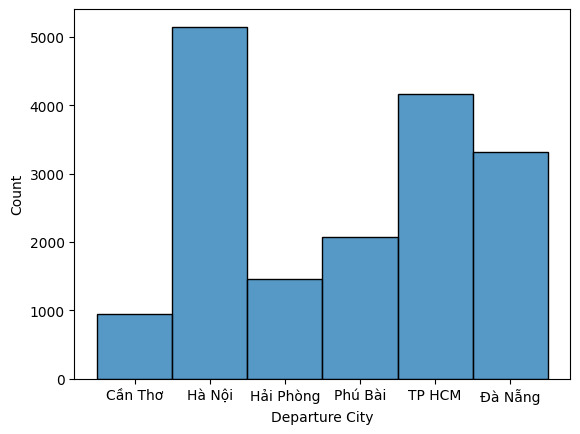

In [16]:
sns.histplot(data=flight_df, x="Departure City");

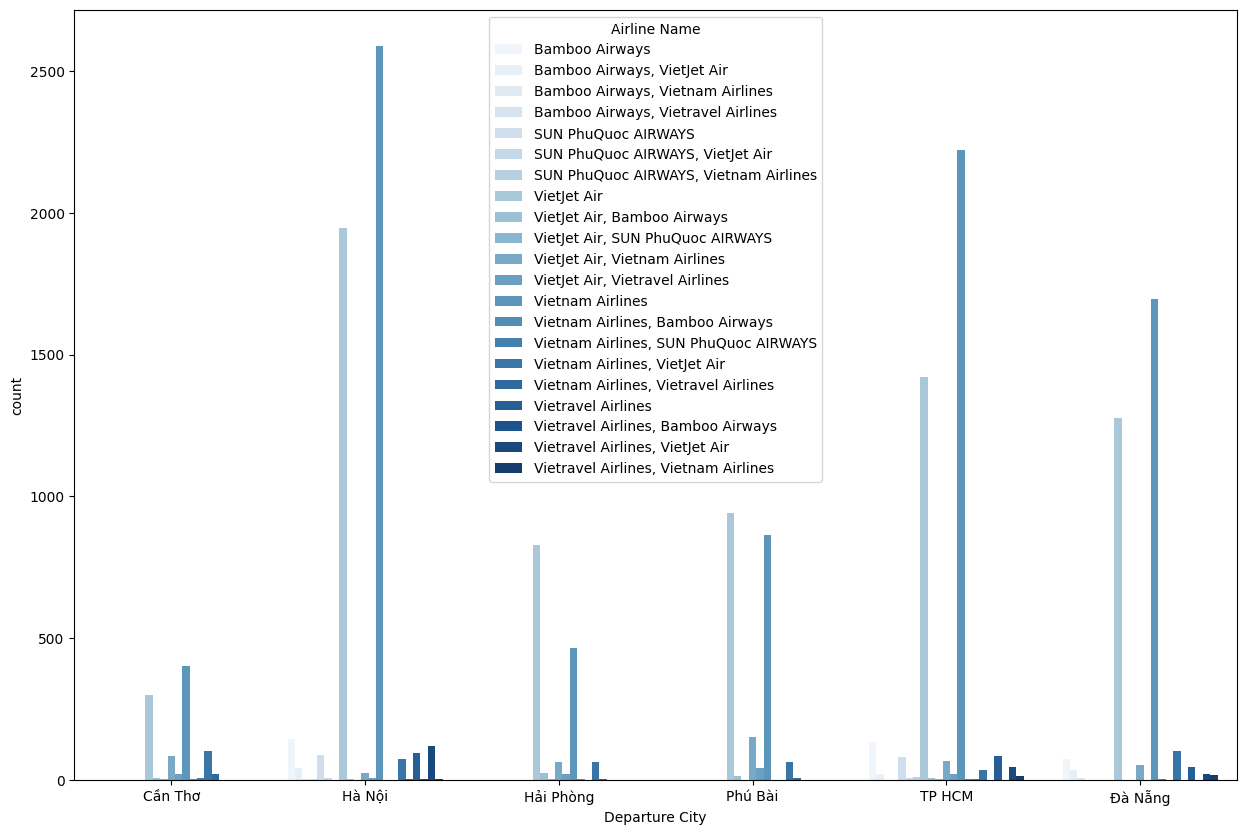

In [17]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.countplot(data=flight_df, x="Departure City", palette="Blues", hue="Airline Name");

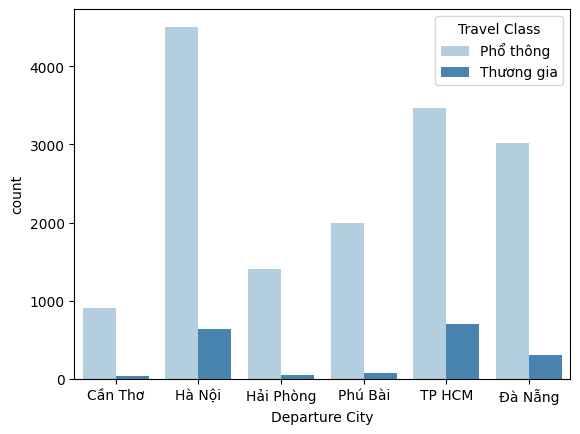

In [18]:

sns.countplot(data=flight_df, x="Departure City", palette="Blues", hue="Travel Class");

In [19]:
flight_df["Arrival City"].value_counts().sort_values(ascending=False)

Arrival City
Hà Nội       4258
TP HCM       4060
Đà Nẵng      3821
Phú Bài      2562
Hải Phòng    1336
Cần Thơ      1092
Name: count, dtype: int64

In [20]:
flight_df["Arrival City"].value_counts(normalize=True).sort_values(ascending=False)

Arrival City
Hà Nội       0.248584
TP HCM       0.237025
Đà Nẵng      0.223072
Phú Bài      0.149571
Hải Phòng    0.077996
Cần Thơ      0.063752
Name: proportion, dtype: float64

In [21]:
flight_df["Stops"].value_counts(normalize=True).sort_values(ascending=True)

Stops
2    0.023702
0    0.310234
1    0.666063
Name: proportion, dtype: float64

<Axes: xlabel='Arrival City', ylabel='count'>

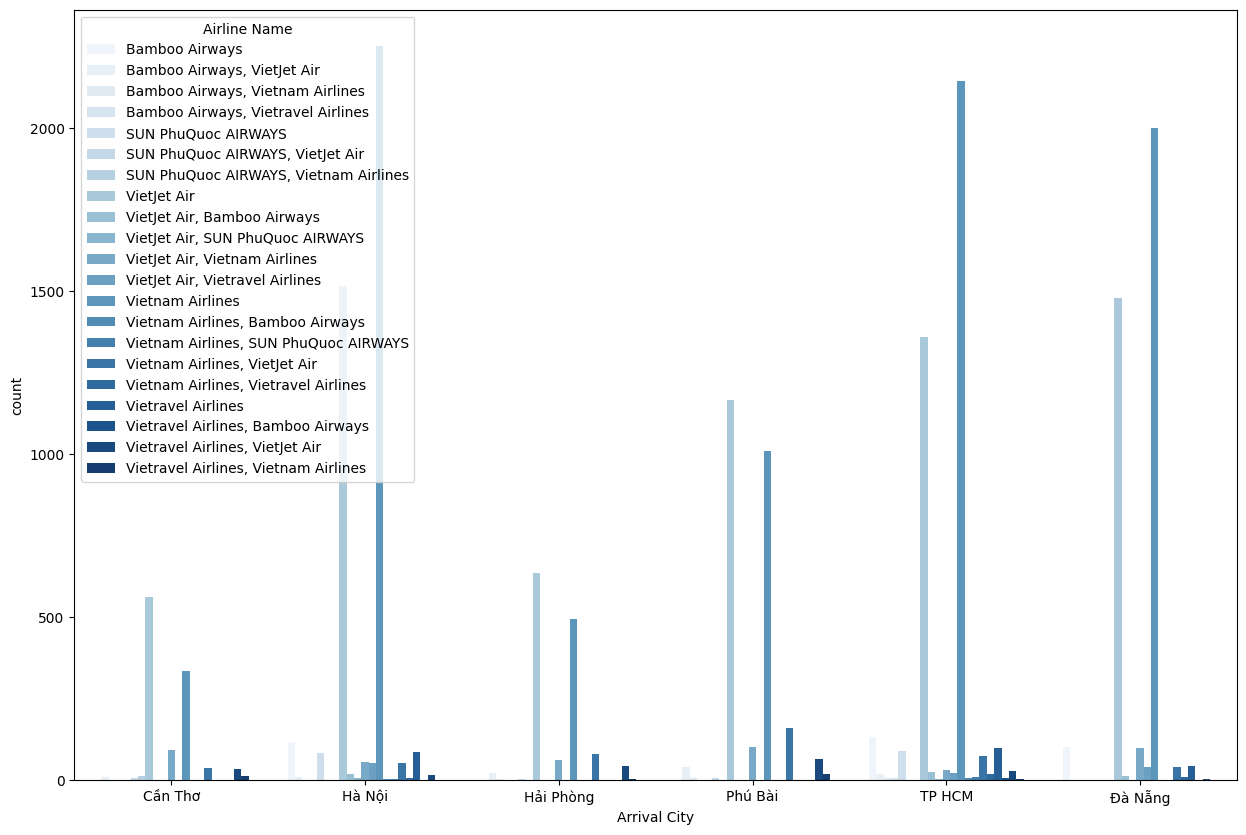

In [22]:
plt.figure(figsize=(15, 10))
sns.countplot(data=flight_df, x="Arrival City", palette="Blues", hue="Airline Name")

In [23]:
flight_df["Travel Class"].value_counts().sort_values(ascending=False)

Travel Class
Phổ thông     15311
Thương gia     1818
Name: count, dtype: int64

<Axes: xlabel='Travel Class', ylabel='count'>

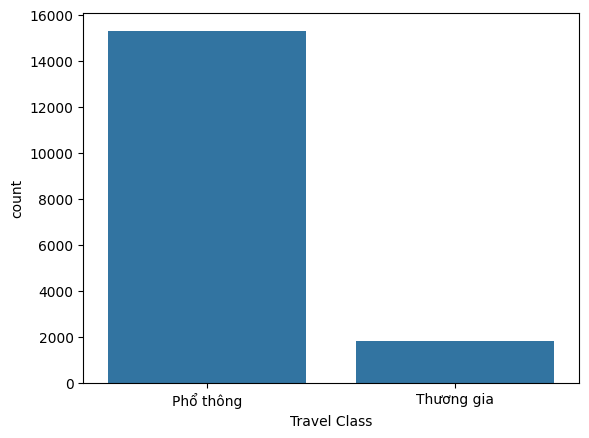

In [24]:
sns.countplot(data=flight_df, x="Travel Class")

<Axes: xlabel='Travel Class', ylabel='count'>

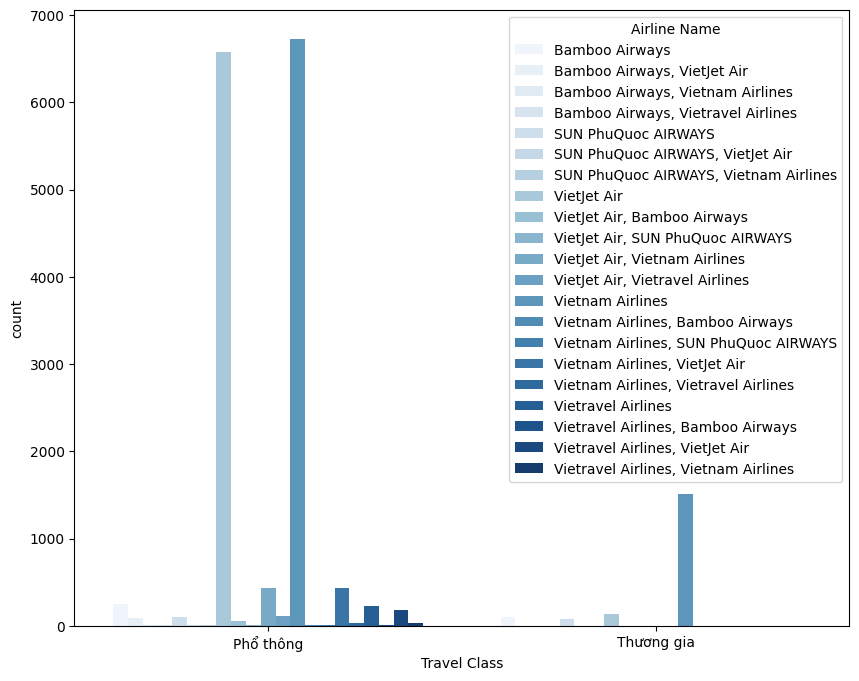

In [25]:
plt.figure(figsize=(10, 8))
sns.countplot(data=flight_df, x="Travel Class", palette="Blues", hue='Airline Name')


In [26]:
# sns.boxplot(data=flight_df, x="day", y="total_bill", hue="sex")

In [27]:
flight_df.Duration.value_counts().head(10)

Duration
2.17    1564
1.33    1018
1.42     743
2.08     674
1.50     407
2.25     386
1.25     231
2.00     200
7.42     104
6.00     104
Name: count, dtype: int64

In [28]:
flight_df["Duration"].median()

np.float64(7.75)

In [29]:
flight_df["Duration"].min()

np.float64(1.17)

In [30]:
flight_df["Duration"].max()

np.float64(41.58)

C:\Users\trita\AppData\Local\Temp\ipykernel_5680\1684259063.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(data=flight_df, x="Duration", bins=40, kde=True, palette="Blues" )


<Figure size 1300x1000 with 0 Axes>

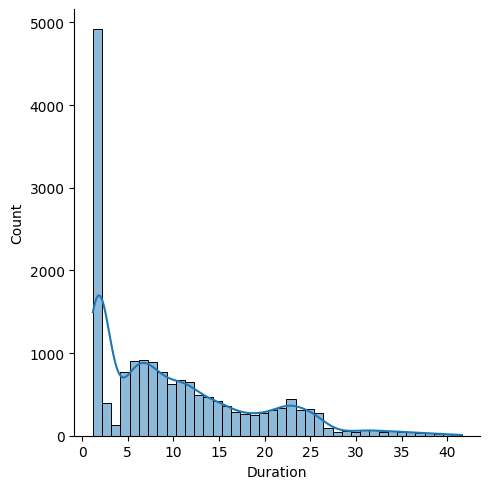

In [31]:
plt.figure(figsize=(13, 10))
sns.displot(data=flight_df, x="Duration", bins=40, kde=True, palette="Blues" )


In [32]:
flight_df["Price"].mean()

np.float64(3394466.402767237)

In [33]:
flight_df[["Airline Name", "Price"]].value_counts().head(10)

Airline Name      Price  
VietJet Air       2852000    170
                  2915406    146
                  2648000    118
                  2079267    115
Vietnam Airlines  8926795    100
VietJet Air       700911      97
                  1368356     94
Vietnam Airlines  8927463     89
VietJet Air       1592858     87
                  2900345     85
Name: count, dtype: int64

In [34]:
flight_df["Price"].value_counts(normalize=True).sort_values(ascending=False).head(10)

Price
2852000    0.009925
2915406    0.008524
2648000    0.006889
2079267    0.006714
8926795    0.005838
700911     0.005663
1368356    0.005488
8927463    0.005196
1592858    0.005079
2900345    0.004962
Name: proportion, dtype: float64

In [35]:
total_ariline_price  = flight_df.groupby("Airline Name")["Price"].sum()
total_ariline_price

C:\Users\trita\AppData\Local\Temp\ipykernel_5680\3884461855.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_ariline_price  = flight_df.groupby("Airline Name")["Price"].sum()


Airline Name
Bamboo Airways                             928496036
Bamboo Airways, VietJet Air                195204219
Bamboo Airways, Vietnam Airlines            22280992
Bamboo Airways, Vietravel Airlines           7225518
SUN PhuQuoc AIRWAYS                        487528771
SUN PhuQuoc AIRWAYS, VietJet Air            38978237
SUN PhuQuoc AIRWAYS, Vietnam Airlines       30091916
VietJet Air                              16946292266
VietJet Air, Bamboo Airways                100660509
VietJet Air, SUN PhuQuoc AIRWAYS            13274481
VietJet Air, Vietnam Airlines             1220409812
VietJet Air, Vietravel Airlines            197806401
Vietnam Airlines                         35866077758
Vietnam Airlines, Bamboo Airways            17266632
Vietnam Airlines, SUN PhuQuoc AIRWAYS       25904876
Vietnam Airlines, VietJet Air             1186812937
Vietnam Airlines, Vietravel Airlines        76743106
Vietravel Airlines                         310055406
Vietravel Airlines, Bamboo Airway

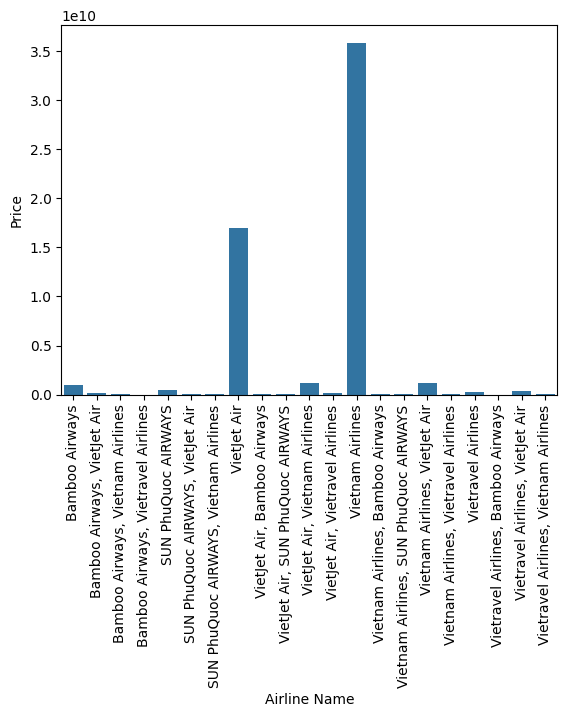

In [36]:

sns.barplot(data=total_ariline_price)
plt.xticks(rotation=90, fontsize=10);


<Axes: xlabel='Price', ylabel='Count'>

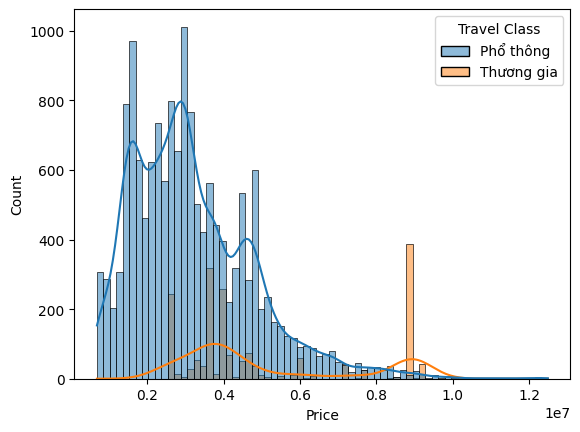

In [37]:
sns.histplot(data=flight_df, x="Price", kde=True, hue="Travel Class")

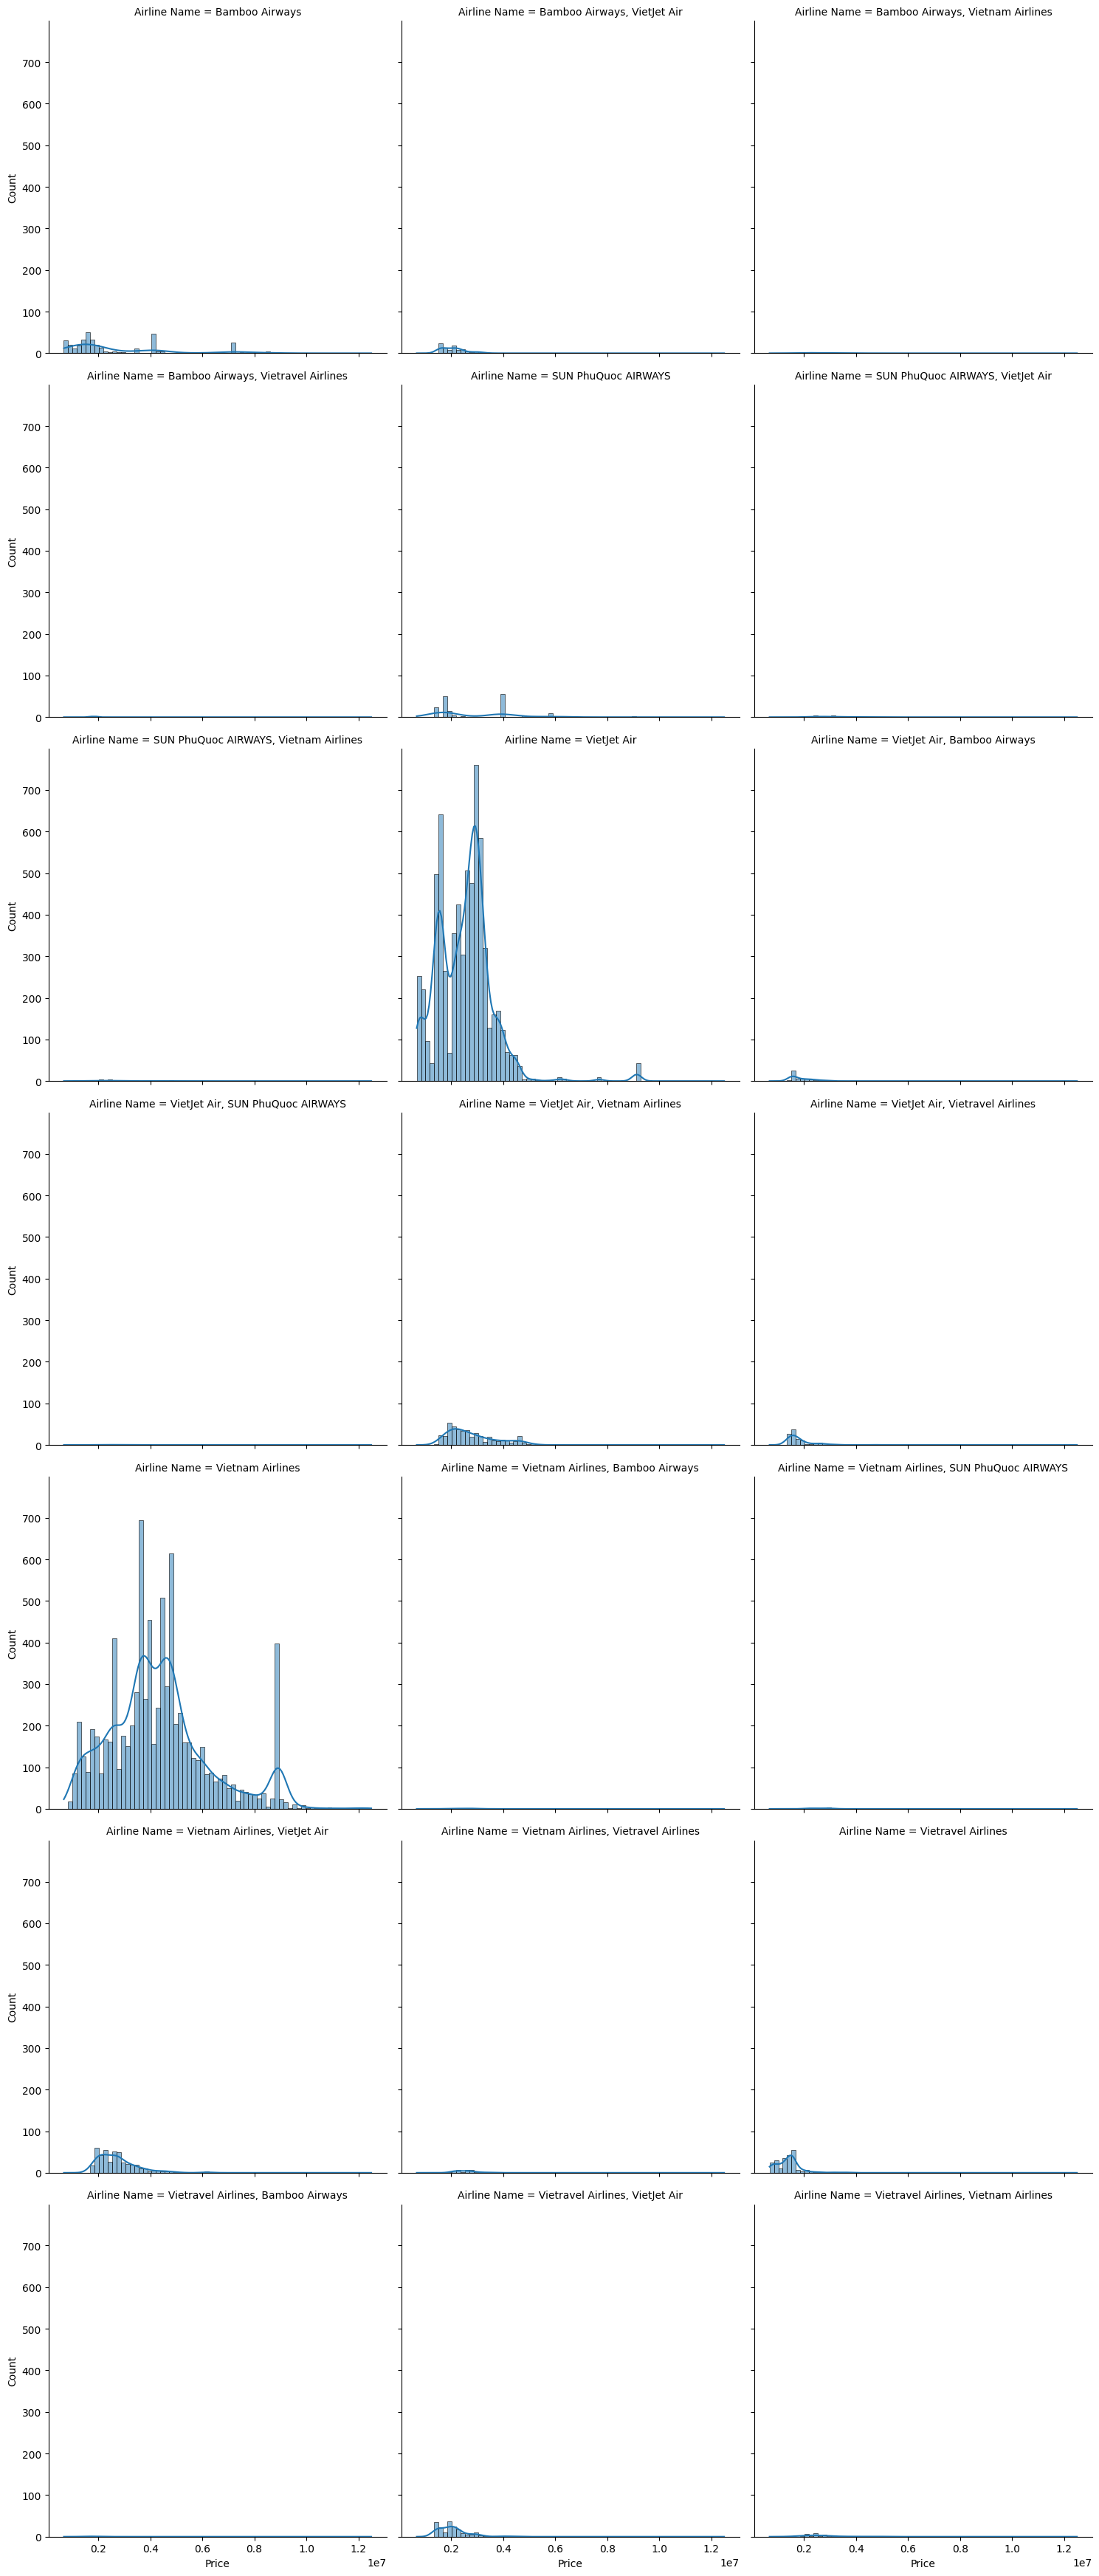

In [38]:

sns.displot(data=flight_df, x="Price", col="Airline Name", kde=True, col_wrap=3); # giá voi cac hang 

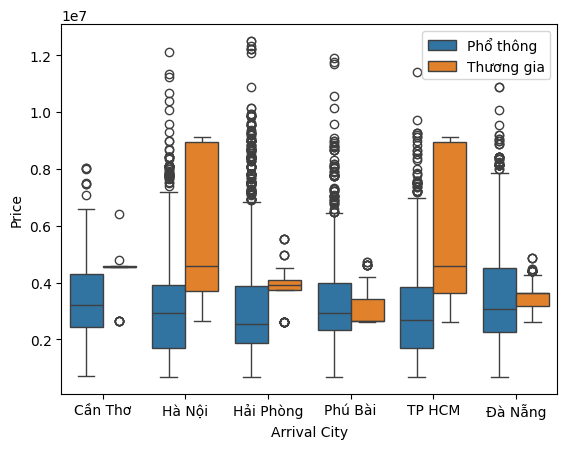

In [39]:
sns.boxplot(data=flight_df, x="Arrival City", y="Price", hue="Travel Class")
plt.legend(loc=0);

### X is data training model

In [40]:
feature = ["Airline Name", "Departure City", "Arrival City", "Travel Class", "Stops", "Departure Time", "Arrival Time", "Duration"]
x = flight_df[feature]
x

,Airline Name,Departure City,Arrival City,Travel Class,Stops,Departure Time,Arrival Time,Duration
0,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,15.58
1,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,14.83
2,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,15.08
3,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Chiều,22.42
4,"VietJet Air, Vietnam Airlines",Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,14.67
...,...,...,...,...,...,...,...,...
17124,"VietJet Air, Vietnam Airlines",TP HCM,Cần Thơ,Phổ thông,2,Tối,Trưa,15.42
17125,"VietJet Air, Vietnam Airlines",TP HCM,Cần Thơ,Phổ thông,2,Trưa,Trưa,25.67
17126,"VietJet Air, Vietnam Airlines",TP HCM,Cần Thơ,Phổ thông,2,Tối,Trưa,17.00
17127,"VietJet Air, Vietnam Airlines",TP HCM,Cần Thơ,Phổ thông,2,Tối,Trưa,17.17


### Y is data predict 

In [41]:
y = flight_df["Price"].values
y

array([1634479, 1857136, 1857136, ..., 4893756, 5173359, 5221230],
      shape=(17129,))

In [42]:
x.head(5)

,Airline Name,Departure City,Arrival City,Travel Class,Stops,Departure Time,Arrival Time,Duration
0,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,15.58
1,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,14.83
2,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,15.08
3,VietJet Air,Hà Nội,Hải Phòng,Phổ thông,1,Tối,Chiều,22.42
4,"VietJet Air, Vietnam Airlines",Hà Nội,Hải Phòng,Phổ thông,1,Tối,Sáng,14.67


# Encoder

### preprecess pipeline
* filling missing values 

In [43]:
cat_feature = ["Airline Name", "Departure City", "Arrival City", "Travel Class", "Stops", "Departure Time", "Arrival Time"]
num_feature = ["Duration"]

In [44]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# ct = StandardScaler()
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])



In [45]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_feature),
    ('num', num_transformer, num_feature)
])

preprocessor.fit(x)

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


 ### Encode Dependent variable(x)

In [46]:
x = preprocessor.transform(x)

# split x_train, y_train, x_val, y_val

In [47]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

x_train, x_test, y_train , y_test = train_test_split(x, y, train_size=(0.7), test_size=0.3)


In [48]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 95920 stored elements and shape (11990, 49)>

In [49]:
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 41112 stored elements and shape (5139, 49)>

In [50]:
y_train

array([1047735, 2852000, 2626094, ..., 2646000, 8820811, 2115017],
      shape=(11990,))

In [51]:
y_test

array([1839218, 4575615, 9190283, ..., 3167035, 4774489, 3007572],
      shape=(5139,))

# Train model

In [52]:
from sklearn.tree import DecisionTreeRegressor
df_model = DecisionTreeRegressor(random_state=42, 
                                max_depth=10,              # Giới hạn độ sâu cây
                                # min_samples_split=10,     # Số mẫu tối thiểu để phân tách
                                # min_samples_leaf=6,       # Số mẫu tối thiểu ở nút lá
                               )
df_model.fit(x_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [53]:
y_predic = df_model.predict(x_test)  # Remove reshape
dt = pd.DataFrame({"Actual": y_test, "Predicted": y_predic})
dt.head(20)

,Actual,Predicted
0,1839218,2.116959e+06
1,4575615,4.899932e+06
2,9190283,4.360955e+06
3,919089,7.779159e+05
4,5095395,4.361478e+06
5,2069254,3.067961e+06
6,3189544,3.585380e+06
7,3480958,3.249481e+06
8,4945150,5.176439e+06
9,3634398,3.387062e+06


In [54]:
# # su dung khi data train duoi dang la datafarme 
# importance = dict(zip(ct.feature_names_in_, ct.feature_importances_))
# sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
# sorted_importance

In [55]:

feature_names = preprocessor.get_feature_names_out()

# Ghép feature importance với tên feature
importance = dict(zip(feature_names, df_model.feature_importances_))

# Sắp xếp giảm dần
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
for name, imp in sorted_importance[:10]:
    print(f"{name}: {imp:.4f}")


num__Duration: 0.3265
cat__Airline Name_Vietnam Airlines: 0.3184
cat__Travel Class_Thương gia: 0.1186
cat__Travel Class_Phổ thông: 0.0511
cat__Arrival City_Hải Phòng: 0.0298
cat__Departure Time_Tối: 0.0240
cat__Stops_1: 0.0220
cat__Departure City_Hải Phòng: 0.0208
cat__Departure City_Đà Nẵng: 0.0156
cat__Arrival Time_Sáng: 0.0098


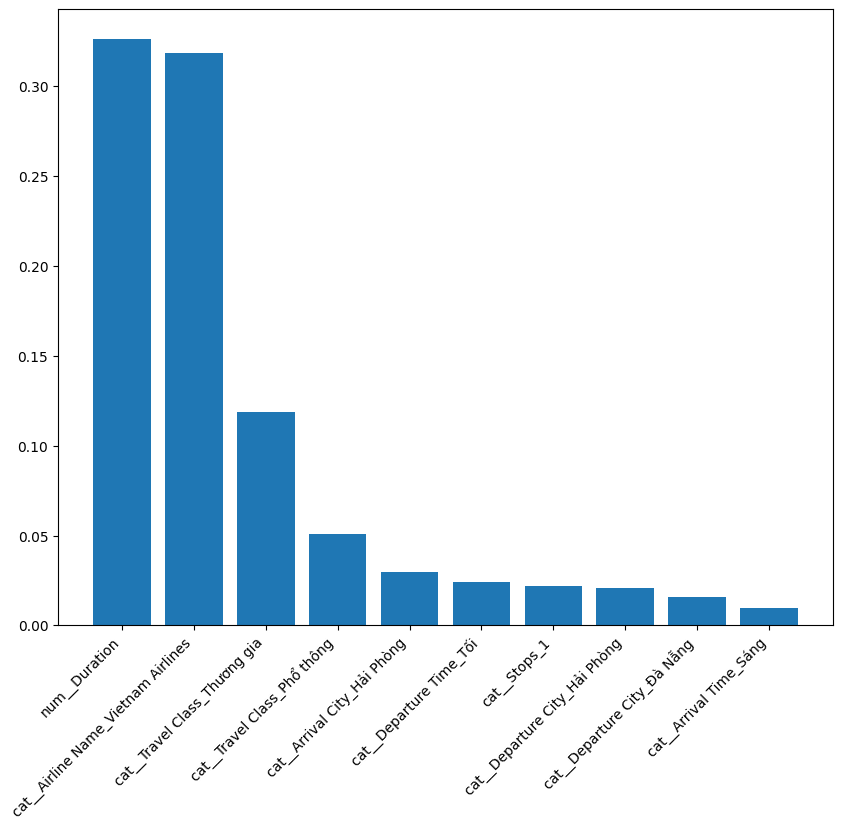

In [56]:
fig, ax = plt.subplots(figsize=(10,8))
ax.bar([x[0] for x in sorted_importance[:10]], [x[1] for x in sorted_importance[:10]])
xlabel = [x[0] for x in sorted_importance[:10]]
plt.xticks(rotation=45, ha='right');

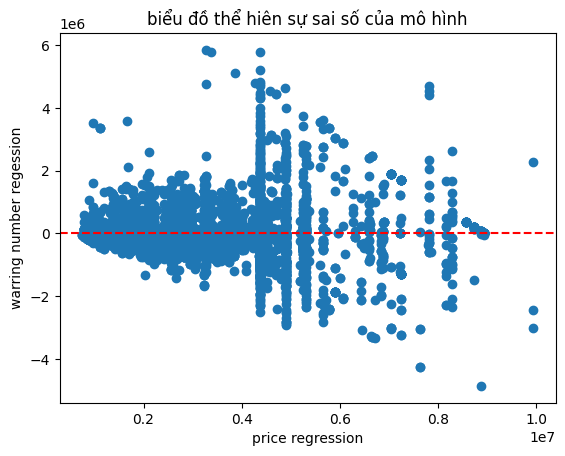

In [57]:
residuals = y_test - y_predic
plt.scatter(y_predic, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("price regression")
plt.ylabel("warring number regession")
plt.title("biểu đồ thể hiên sự sai số của mô hình")
plt.show()


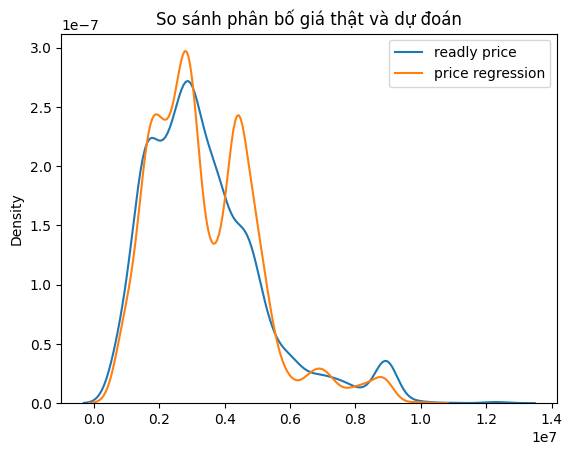

In [58]:
sns.kdeplot(y_test, label="readly price")
sns.kdeplot(y_predic, label="price regression")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đoán")
plt.show()

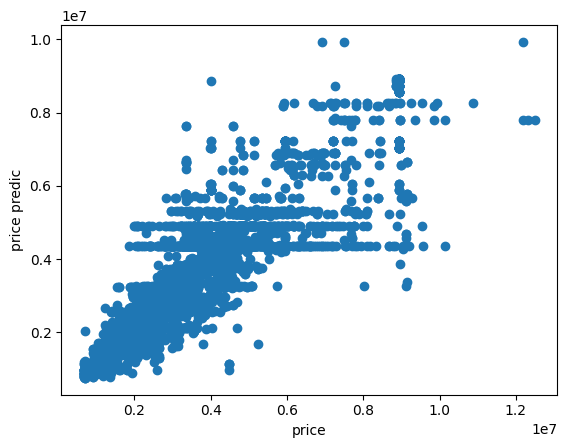

In [59]:
plt.scatter(y_test, y_predic)
plt.xlabel("price")
plt.ylabel("price predic");

In [60]:
from sklearn.ensemble import RandomForestRegressor

rg = RandomForestRegressor(n_jobs=-1)
rg.fit(x_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
import math 
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

y_pred_rg = rg.predict(x_test)
df_reg = pd.DataFrame({"price": y_test, "prediction price to model": y_pred_rg })
df_reg.head(20)

,price,prediction price to model
0,1839218,2.048312e+06
1,4575615,4.911170e+06
2,9190283,4.091675e+06
3,919089,7.786817e+05
4,5095395,4.891492e+06
5,2069254,3.247172e+06
6,3189544,3.558374e+06
7,3480958,3.304859e+06
8,4945150,5.295850e+06
9,3634398,3.657623e+06


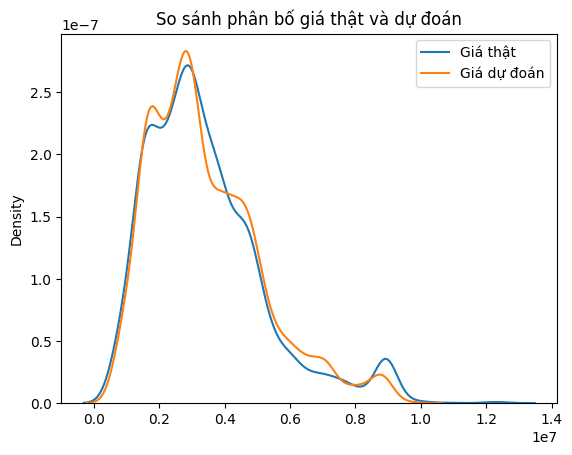

In [62]:
sns.kdeplot(y_test, label="Giá thật")
sns.kdeplot(y_pred_rg, label="Giá dự đoán")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đoán")
plt.show()

Text(0, 0.5, 'price predic')

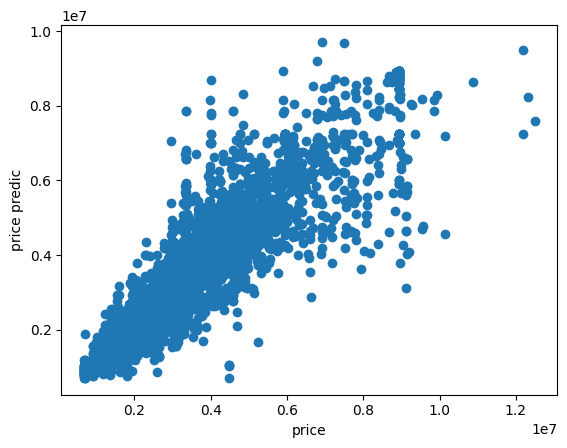

In [63]:
plt.scatter(y_test, y_pred_rg)
plt.xlabel("price")
plt.ylabel("price predic")

In [64]:
print(f"Train accuracy: {df_model.score(x_train, y_train):.4f}")
print(f"Test accuracy: {df_model.score(x_test, y_test):.4f}")

Train accuracy: 0.8256
Test accuracy: 0.7910


In [65]:
print('accuracy', r2_score(y_test, y_pred_rg)) #Đo mức độ mô hình giải thích được biến động của dữ liệu thực tế.
print('MAE', mean_absolute_error(y_test, y_pred_rg)) #Trung bình độ lệch tuyệt đối giữa giá trị thật và dự đoán.→ Càng nhỏ càng tốt
print('MSE', mean_squared_error(y_test, y_pred_rg)) #Trung bình bình phương sai số → nhạy cảm với lỗi lớn.→ Dùng để đo tổng sai lệch mô hình.
print('RMSE', math.sqrt(mean_squared_error(y_test, y_pred_rg))) #Là căn bậc hai của MSE → dễ hiểu hơn vì cùng đơn vị với dữ liệu thật.→ Dùng nhiều để đánh giá độ “sai lệch trung bình” của mô hình.


accuracy 0.8159290827559758
MAE 473095.3862973232
MSE 614074417122.9695
RMSE 783629.0047739233


In [66]:
# # su dung de lay cac feature dac trung tot nhat su dung khi 
# categorical_cols = flight_df.drop("Price", axis=1)  # All columns except 'price'
# feature_names = ct.get_feature_names_out(categorical_cols)

# importance = dict(zip(feature_names, rg.feature_importances_))
# sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# # Display top 10 most important features
# for name, imp in sorted_importance[:]:
#     print(f"{name}: {imp:.4f}")

# Lấy danh sách các feature sau biến đổi (OneHot + numeric)
feature_names = preprocessor.get_feature_names_out()

# Ghép feature importance với tên feature
importance = dict(zip(feature_names, df_model.feature_importances_))
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

for name, imp in sorted_importance[:10]:
    print(f"{name}: {imp:.4f}")

    

num__Duration: 0.3265
cat__Airline Name_Vietnam Airlines: 0.3184
cat__Travel Class_Thương gia: 0.1186
cat__Travel Class_Phổ thông: 0.0511
cat__Arrival City_Hải Phòng: 0.0298
cat__Departure Time_Tối: 0.0240
cat__Stops_1: 0.0220
cat__Departure City_Hải Phòng: 0.0208
cat__Departure City_Đà Nẵng: 0.0156
cat__Arrival Time_Sáng: 0.0098


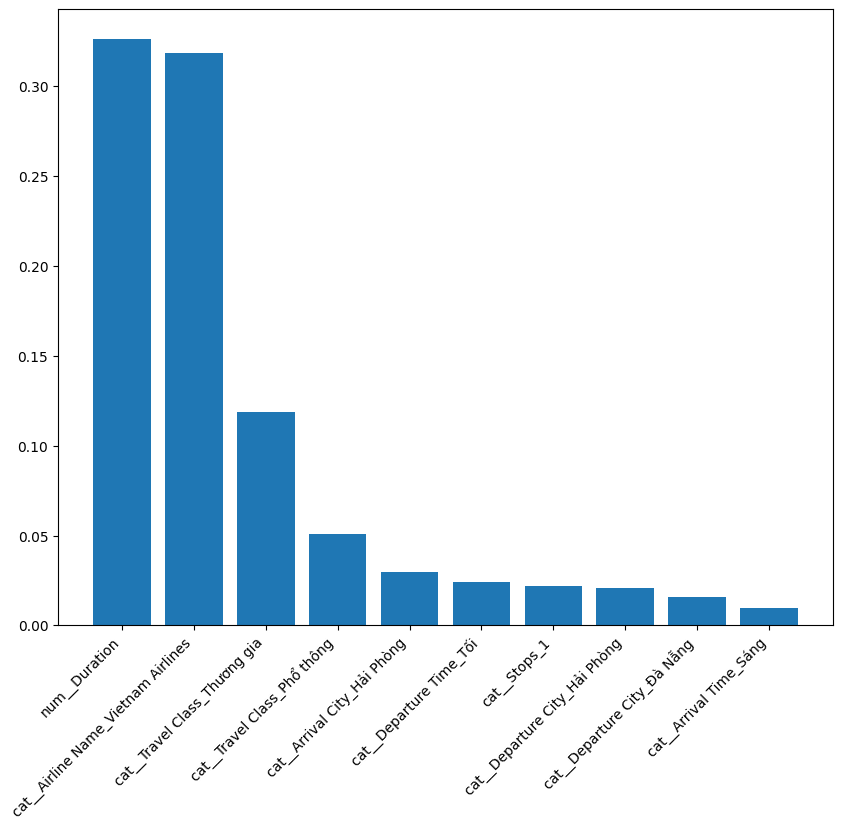

In [67]:
# Danh gia cac nhan  dac trung xuat hien nhieu va tot nhat 
fig, ax = plt.subplots(figsize=(10,8))
ax.bar([x[0] for x in sorted_importance[:10]], [x[1] for x in sorted_importance[:10]])
xlabel = [x[0] for x in sorted_importance[:10]]
plt.xticks(rotation=45, ha='right');

In [68]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)
df_lr = pd.DataFrame({"y": y_test, "y_pred": y_pred_lr})
df_lr.head(20)

,y,y_pred
0,1839218,3.061411e+06
1,4575615,4.474161e+06
2,9190283,4.454462e+06
3,919089,7.398849e+05
4,5095395,4.442199e+06
5,2069254,2.705414e+06
6,3189544,3.172855e+06
7,3480958,4.562391e+06
8,4945150,4.653183e+06
9,3634398,5.258863e+06


In [69]:
# Lấy danh sách các feature sau biến đổi (OneHot + numeric)
feature_names = preprocessor.get_feature_names_out()

# Ghép feature importance với tên feature
importance = dict(zip(feature_names, df_model.feature_importances_))
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

for name, imp in sorted_importance[:10]:
    print(f"{name}: {imp:.4f}")

    

num__Duration: 0.3265
cat__Airline Name_Vietnam Airlines: 0.3184
cat__Travel Class_Thương gia: 0.1186
cat__Travel Class_Phổ thông: 0.0511
cat__Arrival City_Hải Phòng: 0.0298
cat__Departure Time_Tối: 0.0240
cat__Stops_1: 0.0220
cat__Departure City_Hải Phòng: 0.0208
cat__Departure City_Đà Nẵng: 0.0156
cat__Arrival Time_Sáng: 0.0098


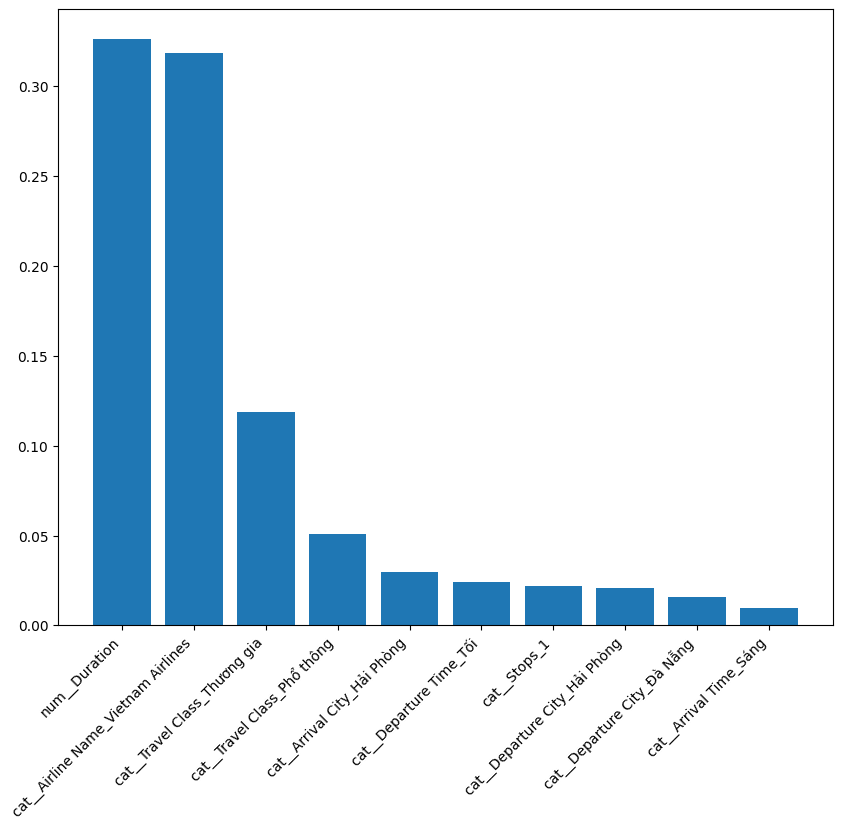

In [70]:
fig, ax = plt.subplots(figsize=(10,8))
ax.bar([x[0] for x in sorted_importance[:10]], [x[1] for x in sorted_importance[:10]])
xlabel = [x[0] for x in sorted_importance[:10]]
plt.xticks(rotation=45, ha='right');

Text(0.5, 1.0, 'So sánh giá trị thực tế và dự đoán theo thời gian')

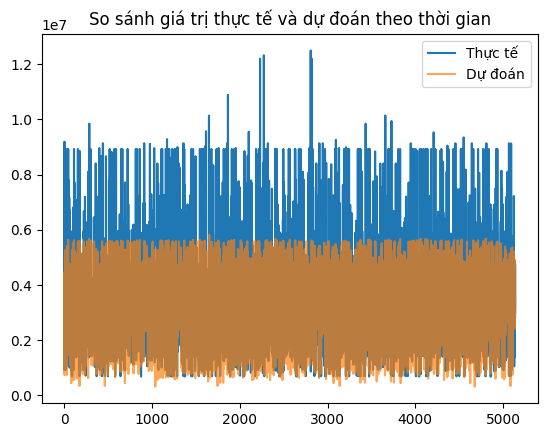

In [71]:
plt.plot(y_test, label="Thực tế")
plt.plot(y_pred_lr, label="Dự đoán", alpha=0.7)
plt.legend()
plt.title("So sánh giá trị thực tế và dự đoán theo thời gian")


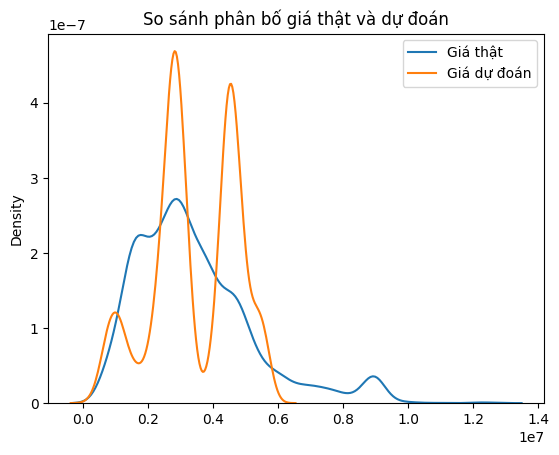

In [72]:
sns.kdeplot(y_test, label="Giá thật")
sns.kdeplot(y_pred_lr, label="Giá dự đoán")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đoán")
plt.show()

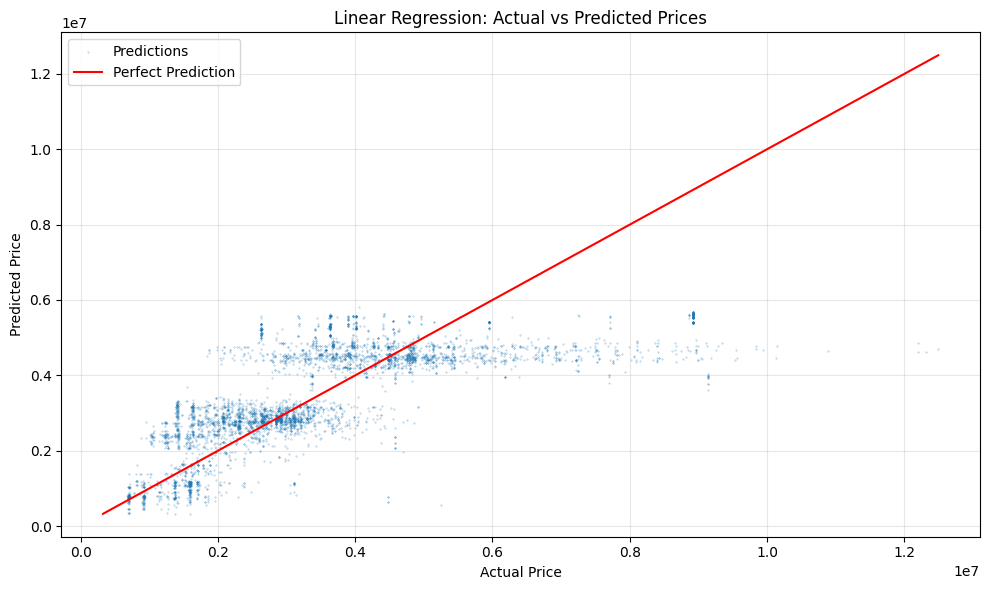

In [73]:

plt.figure(figsize=(10, 6))

# Tính giá trị min, max chính xác
min_val = min(min(y_test), min(y_pred_lr))
max_val = max(max(y_test), max(y_pred_lr))

# Vẽ scatter plot và đường perfect prediction
plt.scatter(y_test, y_pred_lr, alpha=0.5, s=0.1, label='Predictions')
plt.plot([min_val, max_val], [min_val, max_val], label='Perfect Prediction', color="red")

# Thêm labels và title
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted Prices')

# Thêm grid và legend
plt.grid(True, alpha=0.3)
plt.legend()

# Hiển thị plot
plt.tight_layout()
plt.show()

In [74]:
print('accuracy', r2_score(y_test, y_pred_lr)) #Đo mức độ mô hình giải thích được biến động của dữ liệu thực tế.
print('MAE', mean_absolute_error(y_test, y_pred_lr)) #Trung bình độ lệch tuyệt đối giữa giá trị thật và dự đoán.→ Càng nhỏ càng tốt
print('MSE', mean_squared_error(y_test, y_pred_lr)) #Trung bình bình phương sai số → nhạy cảm với lỗi lớn.→ Dùng để đo tổng sai lệch mô hình.
print('RMSE', math.sqrt(mean_squared_error(y_test, y_pred_lr))) #Là căn bậc hai của MSE → dễ hiểu hơn vì cùng đơn vị với dữ liệu thật.→ Dùng nhiều để đánh giá độ “sai lệch trung bình” của mô hình.


accuracy 0.5268387981326892
MAE 878913.2046111923
MSE 1578501338463.3704
RMSE 1256384.2320179644


### Gradient Boosting Regression
* n_estimators: số lượng giai đoạn tăng cường sẽ được thực hiện. Sau đó, chúng ta sẽ vẽ biểu đồ độ lệch so với các lần lặp tăng cường.
* max_depth: giới hạn số lượng nút trong cây. Giá trị tốt nhất phụ thuộc vào sự tương tác của các biến đầu vào.
* min_samples_split: số lượng mẫu tối thiểu cần thiết để chia một nút bên trong.
* learning_rate: mức độ đóng góp của mỗi cây sẽ giảm đi bao nhiêu.
* loss: hàm mất mát để tối ưu hóa. Hàm bình phương nhỏ nhất được sử dụng trong trường hợp này, tuy nhiên, còn có nhiều lựa chọn khác

In [75]:
from sklearn import ensemble
params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}
reg = ensemble.GradientBoostingRegressor(**params) #** giải nén từ điển thành các đối số tên
reg.fit(x_train, y_train)


,loss,'squared_error'
,learning_rate,0.01
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


Top 10 đặc trưng quan trọng nhất:
cat__Airline Name_Vietnam Airlines: 0.3422
num__Duration: 0.3342
cat__Travel Class_Phổ thông: 0.0966
cat__Travel Class_Thương gia: 0.0880
cat__Departure City_Đà Nẵng: 0.0264
cat__Arrival City_Hải Phòng: 0.0152
cat__Departure Time_Tối: 0.0142
cat__Stops_2: 0.0138
cat__Departure City_Hải Phòng: 0.0137
cat__Stops_0: 0.0088


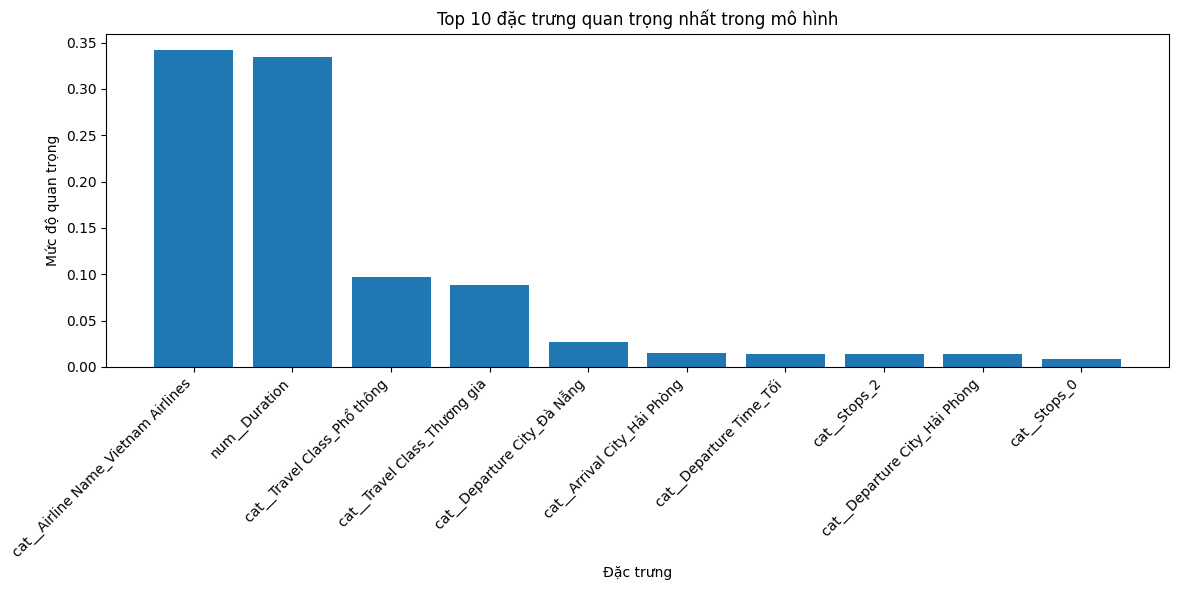

In [76]:
# Lấy tên các đặc trưng
feature_names = preprocessor.get_feature_names_out()
feature_importance = dict(zip(feature_names, reg.feature_importances_))

sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("Top 10 đặc trưng quan trọng nhất:")
for name, importance in sorted_features[:10]:
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(12, 6))
names = [x[0] for x in sorted_features[:10]]
values = [x[1] for x in sorted_features[:10]] 

plt.bar(names, values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Đặc trưng')
plt.ylabel('Mức độ quan trọng')
plt.title('Top 10 đặc trưng quan trọng nhất trong mô hình')
plt.tight_layout()
plt.show()

In [77]:
y_pred_bth = reg.predict(x_test)
df_bth = pd.DataFrame({"y":y_test, "y_predic": y_pred_bth})
df_bth.head(20)

,y,y_predic
0,1839218,2.393831e+06
1,4575615,4.982098e+06
2,9190283,4.780702e+06
3,919089,8.804348e+05
4,5095395,4.570241e+06
5,2069254,2.929730e+06
6,3189544,2.991810e+06
7,3480958,3.934637e+06
8,4945150,5.661380e+06
9,3634398,3.471858e+06


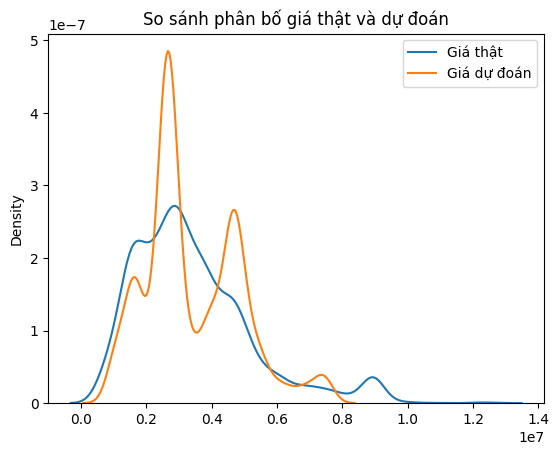

In [78]:
sns.kdeplot(y_test, label="Giá thật")
sns.kdeplot(y_pred_bth, label="Giá dự đoán")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đoán")
plt.show()

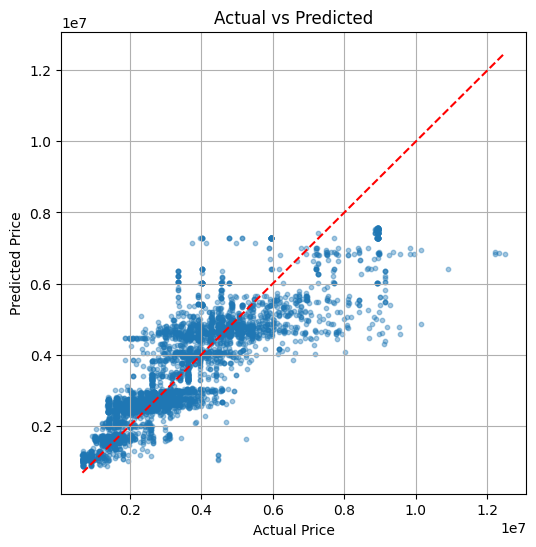

In [79]:

import matplotlib.pyplot as plt
minv, maxv = min(min(y_test), min(y_pred_bth)), max(max(y_test), max(y_pred_bth))
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_bth, alpha=0.4, s=10)
plt.plot([minv, maxv], [minv, maxv], 'r--')
plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

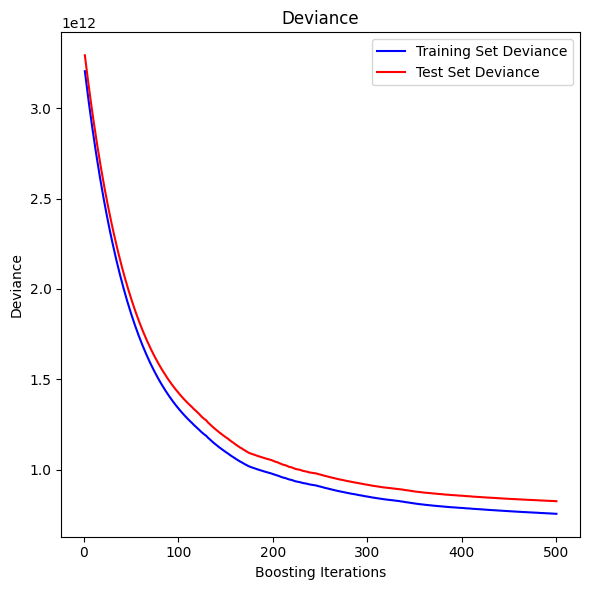

In [80]:
# tính toán độ lệch của tập kiểm tra và sau đó vẽ đồ thị so sánh với các lần lặp tăng cường.
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred_bth in enumerate(reg.staged_predict(x_test)):
    test_score[i] = mean_squared_error(y_test, y_pred_bth)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

In [81]:
print('accuracy', r2_score(y_test, y_pred_lr)) #Đo mức độ mô hình giải thích được biến động của dữ liệu thực tế.
print('MAE', mean_absolute_error(y_test, y_pred_lr)) #Trung bình độ lệch tuyệt đối giữa giá trị thật và dự đoán.→ Càng nhỏ càng tốt
print('MSE', mean_squared_error(y_test, y_pred_lr)) #Trung bình bình phương sai số → nhạy cảm với lỗi lớn.→ Dùng để đo tổng sai lệch mô hình.
print('RMSE', math.sqrt(mean_squared_error(y_test, y_pred_lr))) #Là căn bậc hai của MSE → dễ hiểu hơn vì cùng đơn vị với dữ liệu thật.→ Dùng nhiều để đánh giá độ “sai lệch trung bình” của mô hình.


accuracy 0.5268387981326892
MAE 878913.2046111923
MSE 1578501338463.3704
RMSE 1256384.2320179644


In [82]:
from sklearn.ensemble import StackingRegressor 
estimators = [
    ('lr', LinearRegression()),
    ('Dt', DecisionTreeRegressor(random_state=42))
]
reg_stk = StackingRegressor(
    estimators=estimators,
    final_estimator=RandomForestRegressor(n_estimators=10,
                                          random_state=42)
)

reg_stk.fit(x_train, y_train)
y_pred_stk = reg_stk.predict(x_test)
df_Stk = pd.DataFrame({"y":y_test, "y_predict":y_pred_stk})
df_Stk.head(10)

,y,y_predict
0,1839218,2.424925e+06
1,4575615,4.803018e+06
2,9190283,2.948395e+06
3,919089,7.758499e+05
4,5095395,5.143590e+06
5,2069254,3.140876e+06
6,3189544,3.412392e+06
7,3480958,3.708622e+06
8,4945150,4.588420e+06
9,3634398,3.634965e+06


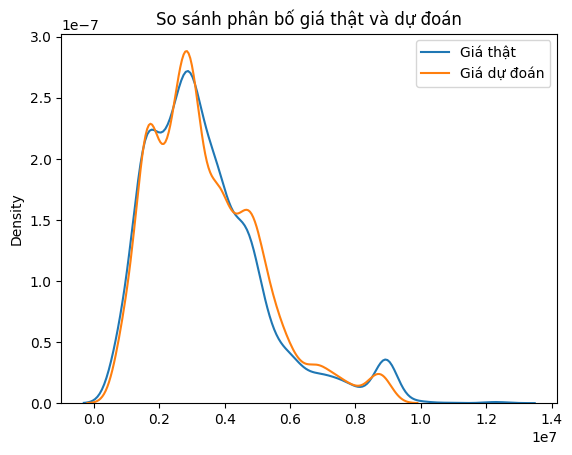

In [83]:
sns.kdeplot(y_test, label="Giá thật")
sns.kdeplot(y_pred_stk, label="Giá dự đoán")
plt.legend()
plt.title("So sánh phân bố giá thật và dự đoán")
plt.show()

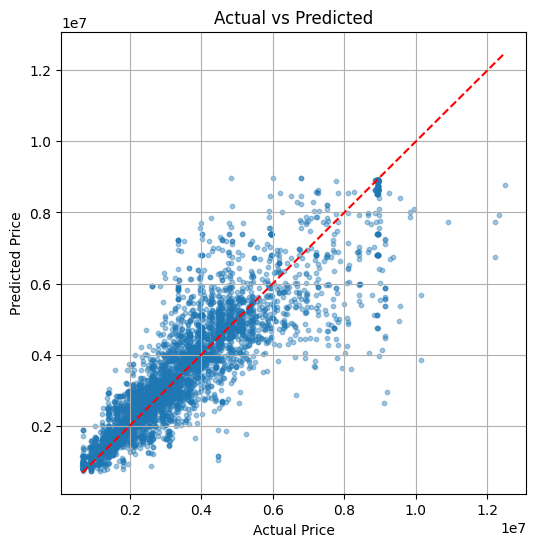

In [84]:

import matplotlib.pyplot as plt
minv, maxv = min(min(y_test), min(y_pred_stk)), max(max(y_test), max(y_pred_stk))
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_stk, alpha=0.4, s=10)
plt.plot([minv, maxv], [minv, maxv], 'r--')
plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

In [85]:
print('accuracy', r2_score(y_test, y_pred_stk)) #Đo mức độ mô hình giải thích được biến động của dữ liệu thực tế.
print('MAE', mean_absolute_error(y_test, y_pred_stk)) #Trung bình độ lệch tuyệt đối giữa giá trị thật và dự đoán.→ Càng nhỏ càng tốt
print('MSE', mean_squared_error(y_test, y_pred_stk)) #Trung bình bình phương sai số → nhạy cảm với lỗi lớn.→ Dùng để đo tổng sai lệch mô hình.
print('RMSE', math.sqrt(mean_squared_error(y_test, y_pred_stk))) #Là căn bậc hai của MSE → dễ hiểu hơn vì cùng đơn vị với dữ liệu thật.→ Dùng nhiều để đánh giá độ “sai lệch trung bình” của mô hình.


accuracy 0.7757151293853752
MAE 543426.3747683058
MSE 748231188578.2029
RMSE 865003.5772054372


In [86]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn import tree

### cross_validation with k_fold (kĩ thuật sử lý tránh overfiting và tăng độ chính xác của model)

In [87]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn import tree
log_reg_cv = LinearRegression()
dt_cv = tree.DecisionTreeRegressor(criterion="squared_error", max_depth=10, random_state=2025)

lr_score = cross_val_score(log_reg_cv, x, y, scoring='r2', cv=5)

In [88]:
lr_score.mean(), lr_score.std()

(np.float64(0.5100207433853852), np.float64(0.05092667456679127))

In [89]:
dt_scores = cross_val_score(dt_cv, x, y, scoring="r2", cv=5)
dt_scores.mean(), dt_scores.std()

(np.float64(0.7744979723977339), np.float64(0.0664127169534854))

In [90]:
seed = 42 
estimators = [
    ('LR', LinearRegression()),
    ('DT', DecisionTreeRegressor(random_state=seed)),
    ('RF', RandomForestRegressor(random_state=seed)),
    ('GBR', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=1.0,
        max_depth=1,
        random_state=seed
    ))
]
model = [
    LinearRegression(),
    DecisionTreeRegressor(random_state=seed),
    RandomForestRegressor(random_state=seed),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=1.0,
        max_depth=1,
        random_state=seed
    ),
    StackingRegressor(
        estimators=estimators,
        final_estimator=RandomForestRegressor(
            n_estimators=10,
            random_state=seed
        )
    )
      
    ]

In [91]:
from sklearn.model_selection import cross_val_score, KFold

def generate_baseline_result_5kfold(models, x, y, metrics="r2", cv=5):
    kfold = KFold(n_splits=cv, shuffle=True, random_state=seed)
    entries = []

    for ml in models:
        model_name = ml.__class__.__name__
        scores = cross_val_score(ml, x, y, scoring=metrics, cv=kfold)

        for fold_index, score in enumerate(scores):
            entries.append((model_name, fold_index, score))

    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "r2_score"])
    return cv_df

In [92]:
models = generate_baseline_result_5kfold(model, x, y, metrics="r2",cv=5)
models

,model_name,fold_id,r2_score
0,LinearRegression,0,0.516549
1,LinearRegression,1,0.548433
2,LinearRegression,2,0.518650
3,LinearRegression,3,0.546179
4,LinearRegression,4,0.524359
5,DecisionTreeRegressor,0,0.790640
6,DecisionTreeRegressor,1,0.813089
7,DecisionTreeRegressor,2,0.801712
8,DecisionTreeRegressor,3,0.797808
9,DecisionTreeRegressor,4,0.818387


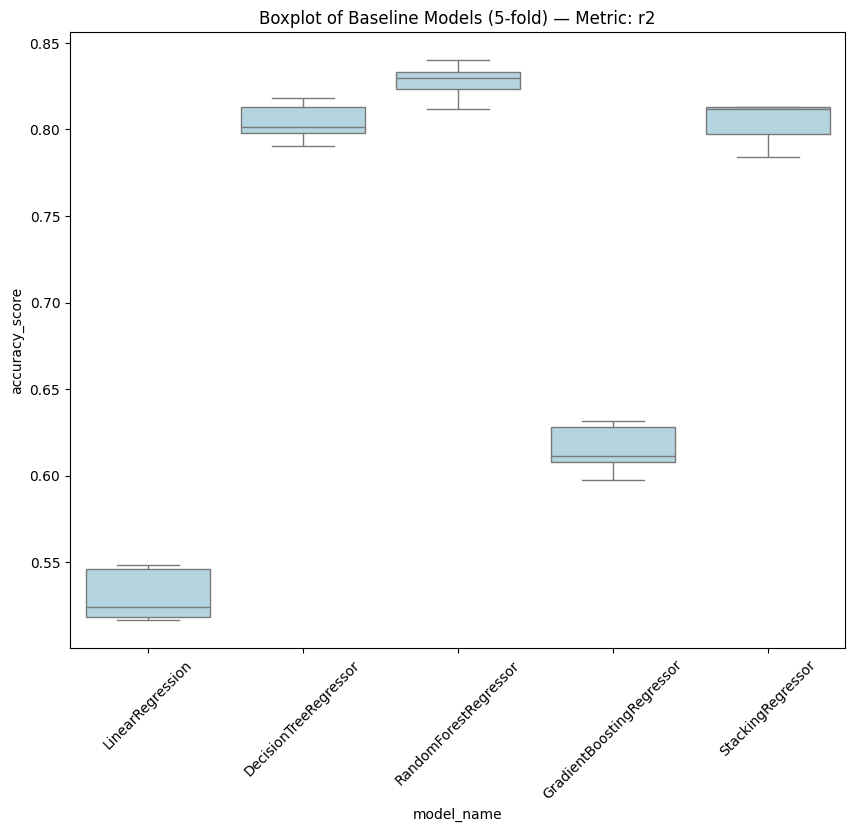

,Mean,Standard Deviation
model_name,,
RandomForestRegressor,0.827561,0.010736
DecisionTreeRegressor,0.804327,0.011304
StackingRegressor,0.803838,0.012835
GradientBoostingRegressor,0.615269,0.014453
LinearRegression,0.530834,0.015327


In [93]:
def generate_baseline_result(model, x, y, metrics="r2", cv=5, plot_result=True):

    # Convert metrics đúng chuẩn sklearn
    if metrics == "logloss":
        scoring = "neg_log_loss"
    else:
        scoring = metrics

    kfold = KFold(cv, shuffle=True, random_state=seed)
    entries = []

    for ml in model:
        model_name = ml.__class__.__name__
        scores = cross_val_score(ml, x, y, scoring=scoring, cv=kfold)
        for fold_index, score in enumerate(scores):
            entries.append((model_name, fold_index, score))
    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "accuracy_score"])
    if plot_result:
        plt.figure(figsize=(10, 8))
        sns.boxplot(x="model_name", y="accuracy_score", data=cv_df, color="lightblue")
        plt.title(f"Boxplot of Baseline Models ({cv}-fold) — Metric: {metrics}")
        plt.xticks(rotation=45)
        plt.show()
    mean = cv_df.groupby("model_name")["accuracy_score"].mean()
    std  = cv_df.groupby("model_name")["accuracy_score"].std()

    baseLine_result = pd.concat([mean, std], axis=1)
    baseLine_result.columns = ["Mean", "Standard Deviation"]

    baseLine_result.sort_values(by="Mean", ascending=False, inplace=True)

    return baseLine_result

generate_baseline_result(model, x, y, metrics="r2", cv=5, plot_result=True)

# Test model with 1 input test 

In [94]:

from datetime import datetime

def convert_time_of_day(dt):
    hour = dt.hour
    if 4 <= hour < 8: return "Sáng sớm"
    if 8 <= hour < 12: return "Sáng"
    if 12 <= hour < 16: return "Trưa"
    if 16 <= hour < 20: return "Chiều"
    return "Tối"

def parse_duration(duration_str):
    h, m = 0, 0
    if "h" in duration_str:
        h = int(duration_str.split("h")[0])
    if "m" in duration_str:
        m = int(duration_str.split("h")[1].split("m")[0])
    return h*60 + m

def predict_price_with_all_models(
    AirlineName,
    DepartureCity,
    Departure_Time,
    Arrival_Time,
    ArrivalCity,
    stops,
    TravelClass,
    Duration
):
    # --- Convert datetime ---
    dep_dt = pd.to_datetime(Departure_Time)
    arr_dt = pd.to_datetime(Arrival_Time)

    # --- Auto generate features ---
    dep_cat = convert_time_of_day(dep_dt)
    arr_cat = convert_time_of_day(arr_dt)
    duration_minutes = parse_duration(Duration)

    today = pd.Timestamp.today()
    days_left = (dep_dt - today).days

    input_data = pd.DataFrame({
        'Airline Name': [AirlineName],
        'Departure City': [DepartureCity],
        'Departure Time': [dep_cat],
        'Stops': [stops],
        'Arrival Time': [arr_cat],
        'Arrival City': [ArrivalCity],
        'Travel Class': [TravelClass],
        'Duration': [duration_minutes],
        'days_left': [days_left],
    })

    # ép kiểu category
    cat_cols = ['Airline Name', 'Arrival City', 'Travel Class', 'Arrival Time', 'Departure Time', 'Stops', 'Departure City']
    for c in cat_cols:
        input_data[c] = input_data[c].astype("category")

    # transform
    input_encoded = preprocessor.transform(input_data)
    predictions = {
        # 'Decition tree': df_model.predict(input_encoded)[0],
        'Random Forest': rg.predict(input_encoded)[0],
        # 'Gradient boosthing': df_bth.predict(input_encoded)[0],
        # 'Linear regression': lr.predict(input_encoded)[0],
        # 'Stacking': reg_stk.predict(input_encoded)[0],
    }
    
    
    print("\nCHI TIẾT CHUYẾN BAY \n")
    print(f"Hãng bay: {AirlineName}")
    print(f"Từ: {DepartureCity}  →  Đến: {ArrivalCity}")
    print(f"Thời gian khởi hành: {Departure_Time} ({dep_cat})")
    print(f"Thời gian đến: {Arrival_Time} ({arr_cat})")
    print(f"Số điểm dừng: {stops}")
    print(f"Hạng vé: {TravelClass}")
    print(f"Thời lượng bay: {Duration} → {duration_minutes} phút")
    print(f"Số ngày đặt trước: {days_left}")

    print("\n KẾT QUẢ DỰ ĐOÁN \n")
    for model, price in predictions.items():
        print(f"{model:15}:  {price:,.0f} VND")


predict_price_with_all_models(
    AirlineName="Vietravel Airlines, Bamboo Airways",
    DepartureCity="Hà Nội",
    Departure_Time="2025-11-18 6:00:00",
    Arrival_Time="2025-11-18 11:40:00",
    ArrivalCity="Hải Phòng",
    stops=0,
    TravelClass="Thương gia",
    Duration="5h 20m"
)




CHI TIẾT CHUYẾN BAY 

Hãng bay: Vietravel Airlines, Bamboo Airways
Từ: Hà Nội  →  Đến: Hải Phòng
Thời gian khởi hành: 2025-11-18 6:00:00 (Sáng sớm)
Thời gian đến: 2025-11-18 11:40:00 (Sáng)
Số điểm dừng: 0
Hạng vé: Thương gia
Thời lượng bay: 5h 20m → 320 phút
Số ngày đặt trước: -26

 KẾT QUẢ DỰ ĐOÁN 

Random Forest  :  6,633,006 VND


In [97]:

from scipy.sparse import issparse
import copy
import joblib
import os
import numpy as np

save_dir = r"D:\predictionFlight\model"
os.makedirs(save_dir, exist_ok=True)

kfold = KFold(n_splits=5, shuffle=True, random_state=2025)

for mdl in model:
    model_name = mdl.__class__.__name__

    fold_scores = []
    fold_models = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(x)):

        # Handle X
        if hasattr(x, "iloc"):
            X_train = x.iloc[train_idx]
            X_val   = x.iloc[val_idx]
        else:
            if issparse(x):
                X_train = x[train_idx].toarray()
                X_val   = x[val_idx].toarray()
            else:
                X_train = x[train_idx]
                X_val   = x[val_idx]

        y_train = y[train_idx]
        y_val   = y[val_idx]

        mdl_clone = copy.deepcopy(mdl)
        mdl_clone.fit(X_train, y_train)

        # Predict & score
        y_pred = mdl_clone.predict(X_val)
        score = r2_score(y_val, y_pred)

        fold_scores.append(score)
        fold_models.append(mdl_clone)

        print(f"{model_name} - Fold {fold+1} R2: {score:.4f}")

    # ===== CHỌN MODEL TỐT NHẤT =====
    mean_score = np.mean(fold_scores)
    best_fold = np.argmax(fold_scores)
    best_model = fold_models[best_fold]

    print(f"🔥 {model_name}")
    print(f"   Mean R2: {mean_score:.4f}")
    print(f"   Best Fold: {best_fold+1}")

    # ===== LƯU DUY NHẤT 1 MODEL =====
    file_path = os.path.join(save_dir, f"{model_name}.pkl")

    joblib.dump(
        {
            "preprocessor": preprocessor,
            "model": best_model,
            "mean_cv_score": mean_score,
            "best_fold": best_fold + 1,
            "fold_scores": fold_scores
        },
        file_path
    )

    print(f"✅ Saved BEST model: {model_name}\n")


LinearRegression - Fold 1 R2: 0.5157
LinearRegression - Fold 2 R2: 0.5402
LinearRegression - Fold 3 R2: 0.5434
LinearRegression - Fold 4 R2: 0.5231
LinearRegression - Fold 5 R2: 0.5321
🔥 LinearRegression
   Mean R2: 0.5309
   Best Fold: 3
✅ Saved BEST model: LinearRegression

DecisionTreeRegressor - Fold 1 R2: 0.8131
DecisionTreeRegressor - Fold 2 R2: 0.8050
DecisionTreeRegressor - Fold 3 R2: 0.7822
DecisionTreeRegressor - Fold 4 R2: 0.8000
DecisionTreeRegressor - Fold 5 R2: 0.8185
🔥 DecisionTreeRegressor
   Mean R2: 0.8038
   Best Fold: 5
✅ Saved BEST model: DecisionTreeRegressor

RandomForestRegressor - Fold 1 R2: 0.8345
RandomForestRegressor - Fold 2 R2: 0.8252
RandomForestRegressor - Fold 3 R2: 0.8171
RandomForestRegressor - Fold 4 R2: 0.8204
RandomForestRegressor - Fold 5 R2: 0.8400
🔥 RandomForestRegressor
   Mean R2: 0.8274
   Best Fold: 5
✅ Saved BEST model: RandomForestRegressor

GradientBoostingRegressor - Fold 1 R2: 0.6063
GradientBoostingRegressor - Fold 2 R2: 0.6141
Gradien

### NOTE 
* accuracy_score: Đây là hàm dùng cho bài toán phân loại (classification), không phù hợp với bài toán dự đoán giá (regression)
* zcore: được sử dụng nhiều trong bài toán dự đoán
